# Intoduction
This is a notebook that documents my attempt to train ollama to predict medical keywords from symptoms and patient details.
I am doing this with synthetic data generated by ChatGPT which you can find in the file 'synthetic_symptom_to_clinical_keywords_100k.csv'
As such the output is not expected to be very accurate. This should only serve a learning exercise for me to understand the process of training an LLM and fine-tuning it for a specific task.

# Order of things
The csv has following columns in it:
    - symptom_description
    - severity
    - duration
    - age_group
    - keywords

I will use the first 4 columns to train the model to predict the last column.
There is an object called `MedicalKeywordsDataItem` that derives from pydantic `BaseModel` and has the following fields:
    - symptom_description: str
    - severity: str
    - duration: str
    - age_group: str
    - keywords: List[str]
Using this, it will help us do a basic sanity check on the data being read in from the CSV.
Next, you need to have an account with hugging face (https://huggingface.co/)[https://huggingface.co/] and generate an access token. 
Have this token as `HF_TOKEN` in the `.env` file.

In [1]:
import os

from dotenv import load_dotenv
from huggingface_hub import login
from transformers import  AutoTokenizer
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from collections import Counter

from medical_keyword import MedicalKeywordsDataItem


In [2]:
load_dotenv(override=True)

HF_TOKEN = os.getenv("HF_TOKEN")
login(token=HF_TOKEN, add_to_git_credential=True)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [25]:
BASE_MODEL = "meta-llama/Llama-3.2-3B"
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

items = MedicalKeywordsDataItem.load_dataset_from_csv("synthetic_symptom_to_clinical_keywords_100k.csv", tokenizer)
print(items[0])

Instruction: Extract the relevant medical keywords from the following symptoms and patient details.            

Input:
Symptoms: Has been having stiff back, pain when bending for roughly 2 weeks.
Severity: moderate
            Duration: 2 weeks
Age Group: teen

Output: Back Pain


In [26]:
token_counts = [item.symptomps_tokens_count for item in tqdm(items)]

  0%|          | 0/100000 [00:00<?, ?it/s]

Let's see the token count distribution

36


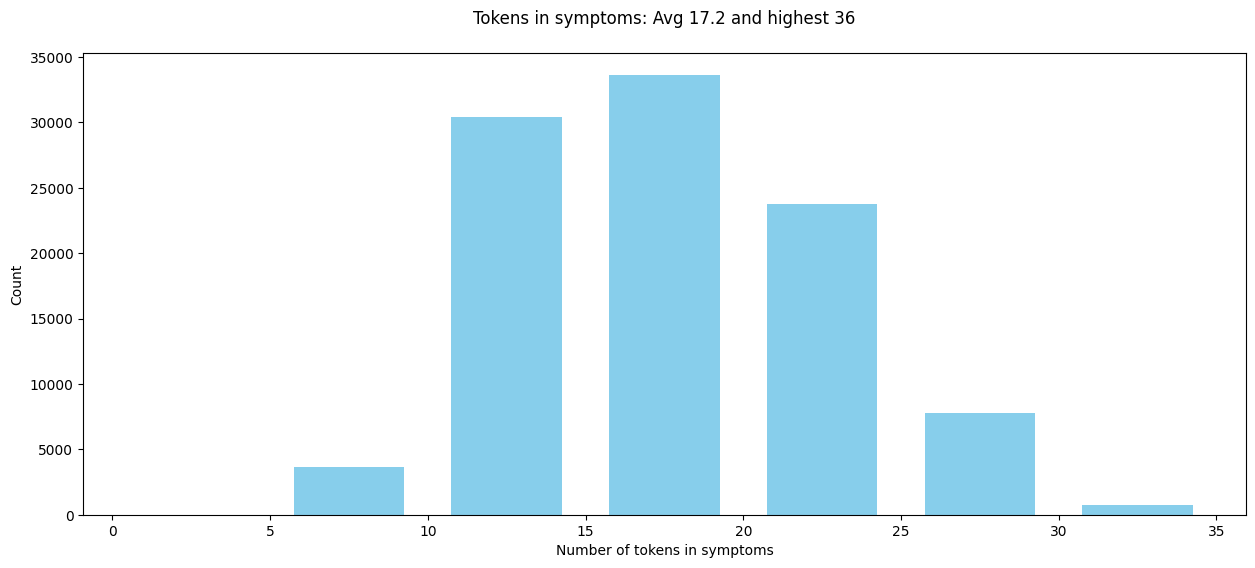

In [27]:
plt.figure(figsize=(15, 6))
print(max(token_counts))
plt.title(f"Tokens in symptoms: Avg {sum(token_counts)/len(token_counts):,.1f} and highest {max(token_counts):,}\n")
plt.xlabel('Number of tokens in symptoms')
plt.ylabel('Count')
plt.hist(token_counts, rwidth=0.7, color="skyblue", bins=range(0, 40, 5))
plt.show()

Let's cutoff the token counts at 30 since this might be a outlier



In [28]:
filtered_items = list(filter(lambda item: item.symptomps_tokens_count < 30, items))
token_counts = [item.symptomps_tokens_count for item in tqdm(filtered_items)]

  0%|          | 0/99279 [00:00<?, ?it/s]

29


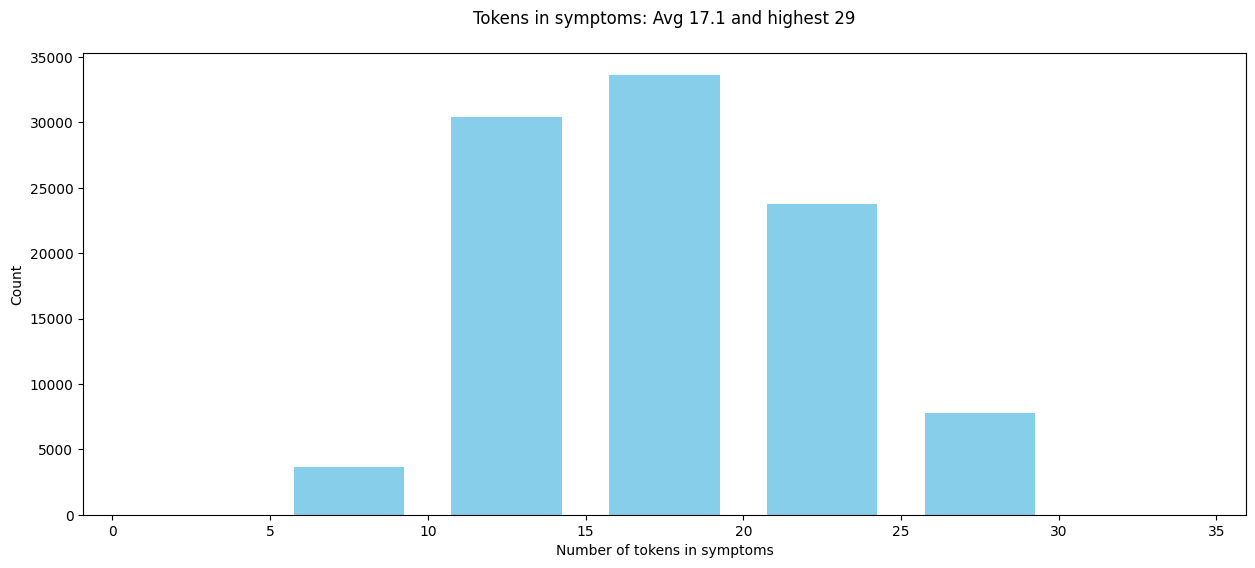

In [29]:
plt.figure(figsize=(15, 6))
print(max(token_counts))
plt.title(f"Tokens in symptoms: Avg {sum(token_counts)/len(token_counts):,.1f} and highest {max(token_counts):,}\n")
plt.xlabel('Number of tokens in symptoms')
plt.ylabel('Count')
plt.hist(token_counts, rwidth=0.7, color="skyblue", bins=range(0, 40, 5))
plt.show()

  0%|          | 0/99279 [00:00<?, ?it/s]

There are 40 unique keywords


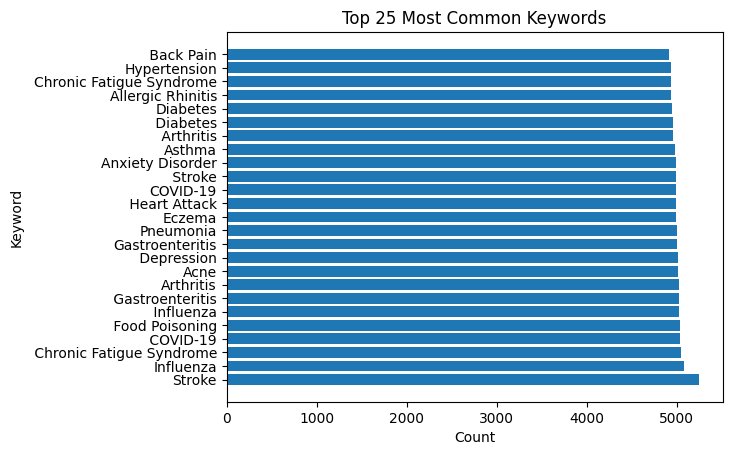

In [30]:
keywords_counter = Counter()

for item in tqdm(filtered_items):
    keywords_counter.update(item.keywords)

print(f"There are {len(keywords_counter)} unique keywords")

# Plot the keywords count
keywords, counts = zip(*keywords_counter.most_common(25))
plt.barh(keywords, counts)
plt.xlabel("Count")
plt.ylabel("Keyword")
plt.title("Top 25 Most Common Keywords")
plt.show()


There are 4 unique age groups
defaultdict(<class 'int'>, {'teen': 25048, 'adult': 24730, 'elderly': 24736, 'child': 24765})


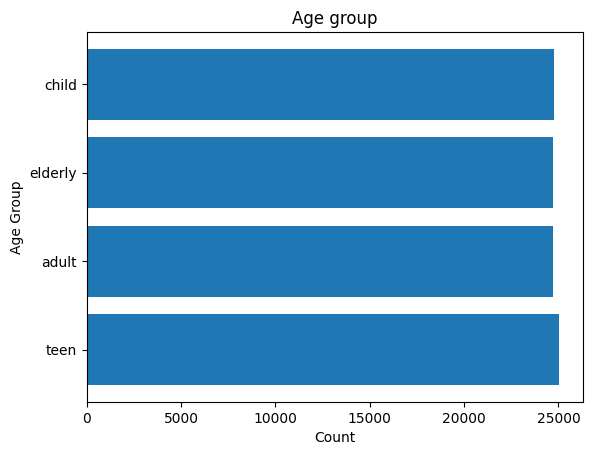

In [31]:
from collections import defaultdict
# Age groups counter
age_groups_counter = defaultdict(int)
for item in filtered_items:  
    age_groups_counter[item.age_group] += 1

print(f"There are {len(age_groups_counter)} unique age groups")
print(age_groups_counter)
# Plot the age groups count 
age_groups = age_groups_counter.keys()
counts = age_groups_counter.values()
plt.barh(age_groups, counts)
plt.xlabel("Count")
plt.ylabel("Age Group")
plt.title("Age group")
plt.show()


Looking at the data above, it feels like the data is evenly distributed across all age groups and across medical keywrods. This could be due to the fact this is synthetic data specifically generated using chat GPT for fine tunining ollama. 

# Upload Data to hugging face
Now we will uplaod the data to HF so that we can use it for fine tuning.

In [50]:
hf_user_name = "navinbhaskar"
data_set_name = "medical_keywords_dataset"

#MedicalKeywordsDataItem.split_and_push_items_to_hub(items, hf_user_name, data_set_name, HF_TOKEN)
dataset = MedicalKeywordsDataItem.convert_items_to_hf_dataset(items)
split_dataset = dataset.train_test_split(test_size=0.2)
MedicalKeywordsDataItem.push_to_hub(split_dataset, hf_user_name, data_set_name, HF_TOKEN)


Setting num_proc from 1 back to 1 for the train split to disable multiprocessing as it only contains one shard.


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

...

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

BadRequestError: (Request ID: Root=1-69b2ef22-1cf82cec334aad716cadf9db;b8652595-cbec-468c-9284-04542068d670)

Bad request for commit endpoint:
Your push was rejected because an LFS pointer pointed to a file that does not exist. For instance, this can happen if you used git push --no-verify to push your changes. Offending file: - data/test-00000-of-00001.parquet - data/train-00000-of-00001.parquet